# Depth-First Search (DFS)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement DFS; compare with BFS

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 06 "Breadth-First Search (BFS)" — same frontier idea, one data structure swapped (queue → stack).

**Used later in:** Course 02 (AIAT 112) — Unit 1, where BFS and DFS are compared on the same graph.

---


## 🎯 The search that verifies the chip in your laptop

Depth-first search with backtracking is the engine inside **SAT solvers**, and
SAT solvers are how modern processors get checked before they are manufactured.
The lineage is precise: the **DPLL** procedure (Davis, Logemann and Loveland,
1962) is depth-first search over variable assignments — pick a variable, commit
to a value, dive as deep as possible, and back out the moment the branch becomes
impossible. Every industrial SAT solver since is DPLL plus learned clauses.

That family exists because of a $475 million bill. Intel's Pentium shipped with a
flawed lookup table in its floating-point division unit; when the flaw became
public in November 1994 Intel recalled the chips and, in its 1994 annual report,
took a **$475 million pre-tax charge** to cover replacing and writing them off.
That bill turned formal hardware verification from an academic interest into an
industrial requirement. Today, checking that a circuit computes
what its specification says is posed as a satisfiability question and handed to a
depth-first backtracking search.

### What goes wrong without depth-first search

BFS in the previous notebook stored an entire frontier. On a verification problem
with 10,000 boolean variables, "an entire level of the tree" has no meaning you
can allocate memory for. DFS stores **one path** — depth, not width. That single
property is why the deepest search problems in computing are solved depth-first,
and it is the trade you are about to see printed.


# Depth-First Search (DFS)

## 📚 Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand the core concepts
- See practical implementations
- Be ready for exercises

**Common Student Questions:**
- **Q: Why use a stack (LIFO) for DFS?**
  - Answer: Stack = Last In First Out → explores deep before wide
  - DFS goes as deep as possible before backtracking
  - Stack stores current path → when backtracking, pops last node → goes deeper
  - Example: Explores A→B→D (deep) before exploring A→C (wide)
- **Q: Why does DFS use less memory than BFS?**
  - Answer: DFS stores only current path in stack (few nodes)
  - BFS stores all nodes at current level in queue (many nodes)
  - Deep graph: DFS stores ~depth nodes, BFS stores ~width nodes
  - Example: Deep tree (depth 100, width 2) → DFS stores ~100, BFS stores ~2^100!
- **Q: Recursive vs iterative DFS - which is better?**
  - Answer: Recursive = simpler code, uses call stack (can overflow)
  - Iterative = more control, uses explicit stack (more memory control)
  - Use recursive: Simple problems, Python handles stack
  - Use iterative: Deep graphs, need to avoid stack overflow
- **Q: When should I use DFS vs BFS?**
  - Answer: DFS = any path, deep exploration, less memory, faster for deep graphs
  - BFS = shortest path, level exploration, more memory, faster for wide graphs
  - Use DFS when: Need any path, graph is deep, memory limited
  - Use BFS when: Need shortest path, graph is wide, memory available

## 🔗 Prerequisites

- ✅ Python 3.8+ installed
- ✅ Required libraries (see `requirements.txt`)
- ✅ Basic Python knowledge

---

## Code Example

Run the code below to see the demonstration:

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

Example 2: Depth-First Search (DFS)

Testing DFS Algorithm (Iterative)

Searching for path from A to F...
  Visiting: A, Path: A
  Visiting: B, Path: A -> B
  Visiting: D, Path: A -> B -> D
  Visiting: E, Path: A -> B -> E
  Visiting: F, Path: A -> B -> E -> F

✓ Goal found! Path: A -> B -> E -> F

Result: ['A', 'B', 'E', 'F']

------------------------------------------------------------
Testing DFS Algorithm (Recursive)
------------------------------------------------------------

Result: ['D', 'B', 'A', 'C']

Example completed successfully!


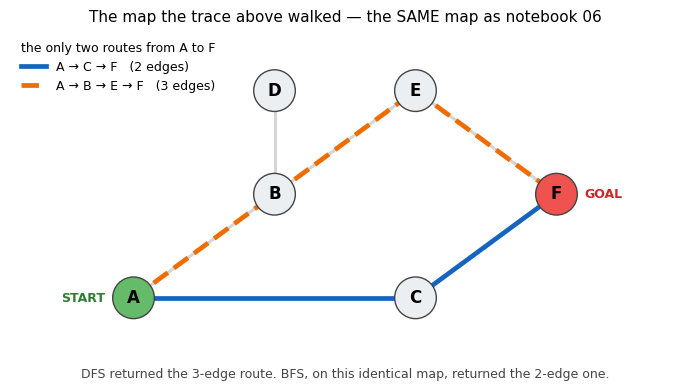


Routes from A to F found by enumeration: A → C → F (2 edges) | A → B → E → F (3 edges)


In [1]:
"""
Unit 1 - Example 07: Depth-First Search (DFS)

This example demonstrates:
1. DFS algorithm implementation
2. Recursive and iterative approaches
3. Finding paths in graphs
"""

print("=" * 60)
print("Example 2: Depth-First Search (DFS)")
print("=" * 60)

# Graph representation
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

def dfs_recursive(graph, node, goal, visited=None, path=None):
    """
    Recursive DFS implementation.
    """
    if visited is None:
        visited = set()
    if path is None:
        path = []
    
    visited.add(node)
    path = path + [node]
    
    if node == goal:
        return path
    
    for neighbor in graph.get(node, []):
        if neighbor not in visited:
            result = dfs_recursive(graph, neighbor, goal, visited, path)
            if result:
                return result
    
    return None

def dfs_iterative(graph, start, goal):
    """
    Iterative DFS implementation using stack.
    """
    stack = [(start, [start])]
    visited = set([start])
    
    print(f"\nSearching for path from {start} to {goal}...")
    
    while stack:
        current, path = stack.pop()
        
        print(f"  Visiting: {current}, Path: {' -> '.join(path)}")
        
        if current == goal:
            print(f"\n✓ Goal found! Path: {' -> '.join(path)}")
            return path
        
        # Add neighbors to stack (reverse order for consistent behavior)
        for neighbor in reversed(graph.get(current, [])):
            if neighbor not in visited:
                visited.add(neighbor)
                stack.append((neighbor, path + [neighbor]))
    
    print(f"\n✗ No path found from {start} to {goal}")
    return None

# Test DFS
print("\n" + "=" * 60)
print("Testing DFS Algorithm (Iterative)")
print("=" * 60)

path1 = dfs_iterative(graph, 'A', 'F')
print(f"\nResult: {path1}")

print("\n" + "-" * 60)
print("Testing DFS Algorithm (Recursive)")
print("-" * 60)

path2 = dfs_recursive(graph, 'D', 'C')
print(f"\nResult: {path2}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

# ── The map, drawn ONCE, with the only two routes from A to F ────────────────
# WHAT: one picture of the same six-node graph the trace above walked, on the FIXED
#       coordinates notebooks 06, 07 and 08 all share, with every A→F route traced.
# WHY : the printed trace is a list of node names. The question the three search
#       notebooks differ on is "which route comes back?" — and you cannot ask that
#       until you can see that there are exactly two of them.
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

POS = {'A': (0, 0), 'B': (1, 1), 'C': (2, 0), 'D': (1, 2), 'E': (2, 2), 'F': (3, 1)}
G_map = nx.Graph()
for _node, _nbrs in graph.items():
    for _nbr in _nbrs:
        G_map.add_edge(_node, _nbr)

# Enumerated, not guessed: ask networkx for every simple path and sort by length.
routes = sorted(nx.all_simple_paths(G_map, 'A', 'F'), key=len)

fig_map, ax_map = plt.subplots(figsize=(7.0, 4.0))
nx.draw_networkx_edges(G_map, POS, ax=ax_map, edge_color='#d5d5d5', width=2.2)
handles = []
for _route, (_col, _style) in zip(routes, [('#1565c0', 'solid'), ('#ef6c00', 'dashed')]):
    nx.draw_networkx_edges(G_map, POS, edgelist=list(zip(_route, _route[1:])), ax=ax_map,
                           edge_color=_col, width=3.4, style=_style)
    handles.append(Line2D([], [], color=_col, lw=3.4, linestyle=_style,
                          label=f"{' → '.join(_route)}   ({len(_route) - 1} edges)"))
_colours = ['#66bb6a' if n == 'A' else '#ef5350' if n == 'F' else '#eceff1'
            for n in G_map.nodes()]
nx.draw_networkx_nodes(G_map, POS, ax=ax_map, node_color=_colours,
                       edgecolors='#444444', node_size=900)
nx.draw_networkx_labels(G_map, POS, ax=ax_map, font_size=12, font_weight='bold')
ax_map.text(POS['A'][0] - 0.20, POS['A'][1], "START", fontsize=9, color='#2e7d32',
            va='center', ha='right', fontweight='bold')
ax_map.text(POS['F'][0] + 0.20, POS['F'][1], "GOAL", fontsize=9, color='#c62828',
            va='center', ha='left', fontweight='bold')
ax_map.legend(handles=handles, loc='upper left', fontsize=9, frameon=False,
              title="the only two routes from A to F", title_fontsize=9)
ax_map.set_title("The map the trace above walked — the SAME map as notebook 06", fontsize=11)
ax_map.text(0.5, -0.06, "DFS returned the 3-edge route. BFS, on this identical map, returned the 2-edge one.", transform=ax_map.transAxes, ha='center',
            fontsize=9, color='#444444')
ax_map.set_axis_off()
ax_map.margins(0.22)
fig_map.tight_layout()
plt.show()

print(f"\nRoutes from A to F found by enumeration: "
      f"{' | '.join(' → '.join(r) + f' ({len(r) - 1} edges)' for r in routes)}")


### 👁️ Read the map

**This is pixel-for-pixel the map from notebook 06** — same six nodes, same
coordinates, same START and GOAL. Nothing about the problem changed; only the
algorithm did.

`networkx` enumerated the routes: exactly **two** exist. Solid blue `A → C → F`
(2 edges) and dashed orange `A → B → E → F` (3 edges).

Now read the trace printed above it: DFS came back with **the dashed orange one**.
BFS, given the identical map, came back with the solid blue one. Neither algorithm
is broken — DFS simply never promised the shortest path, and here is the map on
which it visibly does not deliver one. Keep this picture in view while you read the
storyboard below; it explains *why* DFS walked away from `C` and dived through `B`.


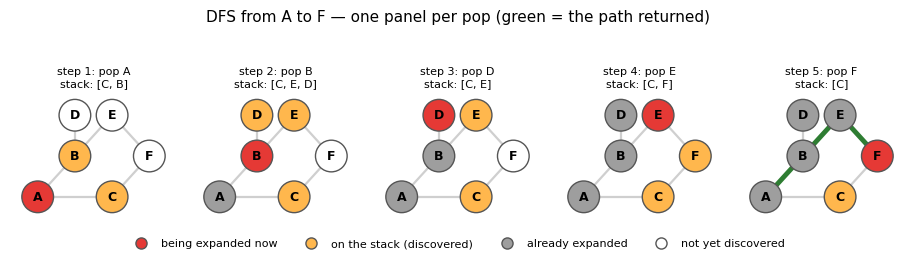

step   pop   stack after (top last)   visited              path so far
   1    A    [C, B]                   {A, B, C}            A
   2    B    [C, E, D]                {A, B, C, D, E}      A -> B
   3    D    [C, E]                   {A, B, C, D, E}      A -> B -> D
   4    E    [C, F]                   {A, B, C, D, E, F}   A -> B -> E
   5    F    [C]                      {A, B, C, D, E, F}   A -> B -> E -> F


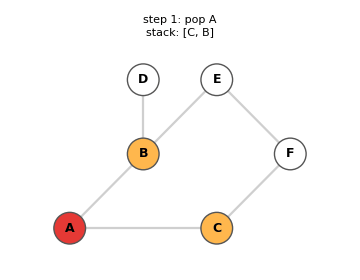


Animated GIF above: 5 frames, 21 KB


In [2]:
# ── Storyboard: watch DFS dive, one expansion at a time ───────────────────────
# WHAT: replay the EXACT iterative-DFS run printed above (A -> F), recording the stack
#       and the visited set at every pop, then draw one panel per step plus a GIF.
# WHY:  BFS spread outward in rings (notebook 06). DFS does the opposite — it commits
#       to one branch and drives to the bottom. That difference is a picture, not a list.
import io

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.lines import Line2D

# The SAME node coordinates as notebooks 06 and 08, so the three storyboards
# can be compared panel for panel on identical geometry.
POS = {'A': (0, 0), 'B': (1, 1), 'C': (2, 0), 'D': (1, 2), 'E': (2, 2), 'F': (3, 1)}

G = nx.Graph()
for node, neighbours in graph.items():
    for neighbour in neighbours:
        G.add_edge(node, neighbour)


def dfs_trace(g, start, goal):
    """Same algorithm as dfs_iterative() above — it RECORDS state instead of printing."""
    stack = [(start, [start])]
    visited = {start}
    steps = []
    while stack:
        current, path = stack.pop()               # LIFO: the newest node wins
        if current != goal:
            for neighbour in reversed(g.get(current, [])):
                if neighbour not in visited:
                    visited.add(neighbour)
                    stack.append((neighbour, path + [neighbour]))
        steps.append({'current': current, 'path': path,
                      'stack': [n for n, _ in stack], 'visited': set(visited)})
        if current == goal:
            break
    return steps


steps = dfs_trace(graph, 'A', 'F')

# Honesty check: the storyboard must show the same run the cell above printed.
assert [s['current'] for s in steps] == ['A', 'B', 'D', 'E', 'F'], "visit order changed"
assert steps[-1]['path'] == path1, "path changed"


def draw_step(ax, s, k, done):
    """Colour every node by its role at step k: expanding / on the stack / done / unseen."""
    expanded = [st['current'] for st in steps[:k]]
    colours = []
    for n in G.nodes():
        if n == s['current']:
            colours.append('#e53935')          # red   = being expanded right now
        elif n in expanded:
            colours.append('#9e9e9e')          # grey  = already expanded
        elif n in s['stack']:
            colours.append('#ffb74d')          # amber = discovered, waiting on the stack
        else:
            colours.append('white')            # white = not discovered yet
    nx.draw_networkx_edges(G, POS, ax=ax, edge_color='#cfcfcf', width=1.6)
    nx.draw_networkx_nodes(G, POS, ax=ax, node_color=colours,
                           edgecolors='#555555', node_size=520)
    nx.draw_networkx_labels(G, POS, ax=ax, font_size=9, font_weight='bold')
    if done:                                    # last panel: the path DFS returned
        p = s['path']
        nx.draw_networkx_edges(G, POS, edgelist=list(zip(p, p[1:])), ax=ax,
                               edge_color='#2e7d32', width=3.5)
    ax.set_title(f"step {k + 1}: pop {s['current']}\nstack: [{', '.join(s['stack']) or '—'}]",
                 fontsize=8)
    ax.set_axis_off()
    ax.margins(0.18)


n_steps = len(steps)
fig, axes = plt.subplots(1, n_steps, figsize=(1.85 * n_steps, 2.5))
for k, (ax, s) in enumerate(zip(axes, steps)):
    draw_step(ax, s, k, done=(k == n_steps - 1))
legend = [Line2D([], [], marker='o', linestyle='', markersize=8, markerfacecolor=c,
                 markeredgecolor='#555', label=l)
          for c, l in [('#e53935', 'being expanded now'), ('#ffb74d', 'on the stack (discovered)'),
                       ('#9e9e9e', 'already expanded'), ('white', 'not yet discovered')]]
fig.legend(handles=legend, loc='lower center', ncol=4, frameon=False, fontsize=8)
fig.suptitle('DFS from A to F — one panel per pop (green = the path returned)', fontsize=11)
fig.tight_layout(rect=[0, 0.09, 1, 0.93])
plt.show()

# The same storyboard as a table you can read out loud in class.
print(f"{'step':>4}  {'pop':^5}  {'stack after (top last)':<24} {'visited':<20} path so far")
for k, s in enumerate(steps, 1):
    print(f"{k:>4}  {s['current']:^5}  {'[' + ', '.join(s['stack']) + ']':<24} "
          f"{'{' + ', '.join(sorted(s['visited'])) + '}':<20} {' -> '.join(s['path'])}")

# Animated version of the very same frames (the repo's Course 09 step-viz idiom:
# render frames -> encode a GIF -> display it). The grid above is the fallback.
try:
    from IPython.display import Image as IPyImage, display
    from PIL import Image

    frames = []
    for k, s in enumerate(steps):
        f2, ax2 = plt.subplots(figsize=(3.6, 2.8), dpi=100)
        draw_step(ax2, s, k, done=(k == n_steps - 1))
        f2.tight_layout()
        f2.canvas.draw()
        frames.append(Image.fromarray(np.asarray(f2.canvas.buffer_rgba())[:, :, :3]))
        plt.close(f2)
    buf = io.BytesIO()
    frames[0].save(buf, format='GIF', save_all=True, append_images=frames[1:],
                   duration=900, loop=0)
    display(IPyImage(data=buf.getvalue()))
    print(f"\nAnimated GIF above: {len(frames)} frames, {len(buf.getvalue()) / 1024:.0f} KB")
except Exception as exc:                        # pragma: no cover - display convenience only
    print(f"\n(GIF skipped: {exc}) — the frame grid above carries the same information.")


### 👁️ Read the storyboard — and put it next to notebook 06

Same graph, same node positions, same colours as the BFS storyboard: red is the
node being expanded now, amber is discovered-and-waiting (on the **stack** this
time, not a queue), grey is already expanded, white is unseen. Green edges in the
last panel are the path DFS returned.

**What the picture proves:**

- **DFS dives; BFS spread.** After step 1 the stack is `[C, B]` and DFS pops **B**
  — the node it pushed *last*. It then keeps taking the newest node, so the red
  marker walks A → B → D → E → F, deeper on almost every step, instead of filling
  a ring.
- **Look at C in every panel.** C is discovered at step 1 and is still amber at
  step 5. It sits at the bottom of the stack while the search burrows down the
  other branch — even though C is one hop from A and one hop from the goal. DFS
  never comes back for it, which is exactly why the path it returns
  (`A → B → E → F`, 3 edges) is longer than the one BFS found (`A → C → F`, 2 edges).
- **Fewer panels is not better.** DFS used **5** expansions to BFS's **6** and
  returned a path 50% longer. The panel count measures work done, not answer quality.

**A backtrack is the panel you cannot see here.** On this small graph DFS happened
to walk straight to the goal. Delete the E–F edge and step 5 would pop C off the
bottom of the stack — the search "teleporting" back across the graph. That jump is
DFS's defining move, and it is why the path it returns has no length guarantee.


## 📊 Read the two traces against notebook 06

Both notebooks ran on the **same six-node graph**, A to F:

| | nodes visited | path returned | edges |
|---|---|---|---|
| BFS (notebook 06) | 6 — A, B, C, D, E, F | A → C → F | **2** |
| **DFS (this notebook)** | **5 — A, B, D, E, F** | **A → B → E → F** | **3** |
| A* (notebook 08) | 4 — A, B, C, F | A → C → F | 2 |

**The conclusion these runs actually support:** DFS visited one node fewer and
returned a path **50% longer**. That is the whole trade in one line — DFS gives
up the shortest-path guarantee and gets memory proportional to *depth* instead of
*width*. On this six-node toy the saving is one node and the cost is one edge.
On a graph deep enough to matter, the saving is the difference between running
and running out of memory, and the cost is a route nobody would drive.

Notice also the second run in the output: recursive DFS from D to C returned
`D → B → A → C`. There was no shorter path, so here DFS was optimal — by luck of
the graph, not by guarantee. **A single lucky run is not evidence of a property.**


## 💬 Discuss

1. DFS found F one node sooner and returned a worse path. Name a real search
   problem where you would take that trade without hesitating, and one where you
   would refuse it. What feature of the problem decides?
2. The iterative version uses an explicit stack; the recursive version uses
   Python's call stack, which raises `RecursionError` at around a thousand frames.
   For a graph 10,000 levels deep, does that make the recursive version *wrong*,
   or just *inconvenient*? Argue it as if you were reviewing a colleague's pull request.
3. A SAT solver checking a chip must eventually explore every branch that could
   contain a bug. A route planner may stop at the first acceptable answer.
   **How does "I need any solution" versus "I need to prove none exists" change
   which of BFS, DFS and A* you reach for?**


---

## ✅ Summary

Great job completing this example!

**What you learned:**
- Core concepts demonstrated in the code
- Practical implementation details

**Next steps:**
- Complete the exercises in `exercises/` folder
- Review the quiz materials
- Proceed to the next example

---

**💡 Tip:** If you see errors, make sure:
- All libraries are installed: `pip install -r requirements.txt`
- You're using Python 3.8+
- Cells are executed in order

## ⚠️ Where this breaks

- **DFS returns a path, never the path.** Our own output proves it: three edges
  where two exist. If your report or your product says "shortest", DFS is the
  wrong algorithm and no amount of tuning fixes that. **Use instead:** BFS
  (unweighted), Dijkstra (weighted), or iterative-deepening DFS if you need
  DFS-style memory *and* the shortest-path guarantee.
- **Without the visited set it does not terminate.** This graph contains the cycle
  A–B–E–F–C–A. Remove `visited` and the iterative version loops forever while the
  recursive version dies with a `RecursionError`. On an infinite or generated
  state space (a game tree, a crawler), even *with* a visited set DFS can descend
  a single infinite branch and never come back — it is **not complete** there.
  The standard fix is a depth limit.
- **Recursion depth is a hard ceiling in Python.** CPython's default limit is
  about 1,000 frames. Raising it risks a segmentation fault rather than a clean
  exception. For deep graphs, write the explicit-stack version.
- **The exploration order is an artefact of your data structure.** DFS went to B
  before C only because `graph['A']` lists `['B', 'C']` in that order. Reorder the
  adjacency lists and you get a different path with the same code — which means
  you cannot reproduce someone else's DFS result without their exact input ordering.
- **The assumption that must hold:** you want *a* solution, the search space is
  deeper than it is wide, and either the space is finite or you have imposed a
  depth limit. Break any of those and reach for a different algorithm.


## 📚 References

1. Tarjan, R. (1972). *Depth-First Search and Linear Graph Algorithms*. SIAM Journal on Computing, 1(2), 146–160.
2. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Ch. 3: Solving Problems by Searching. Pearson.
3. Gandhi, K., Lee, D., Grand, G., et al. (2024). *Stream of Search (SoS): Learning to Search in Language*. arXiv. <https://arxiv.org/abs/2404.03683>
4. Muennighoff, N., Yang, Z., Shi, W., et al. (2025). *s1: Simple test-time scaling*. arXiv. <https://arxiv.org/abs/2501.19393>